SGDRegressor — это модель линейной регрессии, которая обучается итеративно с использованием стохастического градиентного спуска (Stochastic Gradient Descent, SGD).


Эта модель полезна, если:

- Данных очень много, и аналитическое решение тормозит. Вычисление через точную формулу требует обращения матриц, что при больших объёмах данных сильно нагружает память и процессор.
- Нужна регуляризация. Регуляризация поможет избежать переобучения, добавляя штрафы за сложность модели.
- Данные приходят потоками. Стохастический градиентный спуск обновляет модель тут же, как новые данные поступают, и вы сразу дообучаете модель без хранения всей выборки.
- Хотите управлять процессом обучения. Численные методы позволяют задавать параметры, например, размер шага ( learning rate ), что даёт больше гибкости.


## Самые важные параметры SGDRegressor:

- `learning_rate` - шаг обучения
- `eta0` - начальное значение шага обучения
- `max_iter` - максимальное количество итераций
- `tol` - критерий остановки обучения
- `random_state` - фиксирует начальное состояние генератора случайных чисел для воспроизводимости результатов


Документация: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDRegressor.html


## Реализация модели


In [3]:
import numpy as np
from sklearn.datasets import make_regression
from sklearn.linear_model import SGDRegressor

In [4]:
## Для примера зададим свои параметры
model_sgd = SGDRegressor(
    learning_rate='constant',  # фиксированный шаг обучения
    eta0=0.01,                 # размер шага
    max_iter=1000,             # максимальное число проходов по данным
    tol=1e-3,                  # критерий остановки по изменению ошибки
    random_state=42            # фиксируем для воспроизводимости
)

In [6]:
# Создадим синтетический датасет для регрессии на 200 образцах и 5 признаках
X, y = make_regression(
    n_samples=200,
    n_features=5,
    noise=15,
    random_state=42
)

In [7]:
# Обучение модели на данных
model_sgd.fit(X, y)

# Вывод коэффициентов и свободного члена
print("Коэффициенты:", model_sgd.coef_)
print("Свободный член:", model_sgd.intercept_)

Коэффициенты: [ 3.70860355  9.86772738 64.85114448 18.25190004 70.99376366]
Свободный член: [1.1265664]


In [8]:
# Получение и вывод первых 10 предсказаний
y_pred_sgd = model_sgd.predict(X)
print(y_pred_sgd[:10])

[ -23.87311444 -129.04151225    0.8990526   -76.49924926   12.4813682
 -192.08702264  -28.15963751   38.36050803  119.56532941  124.9523802 ]


In [10]:
import matplotlib.pyplot as plt

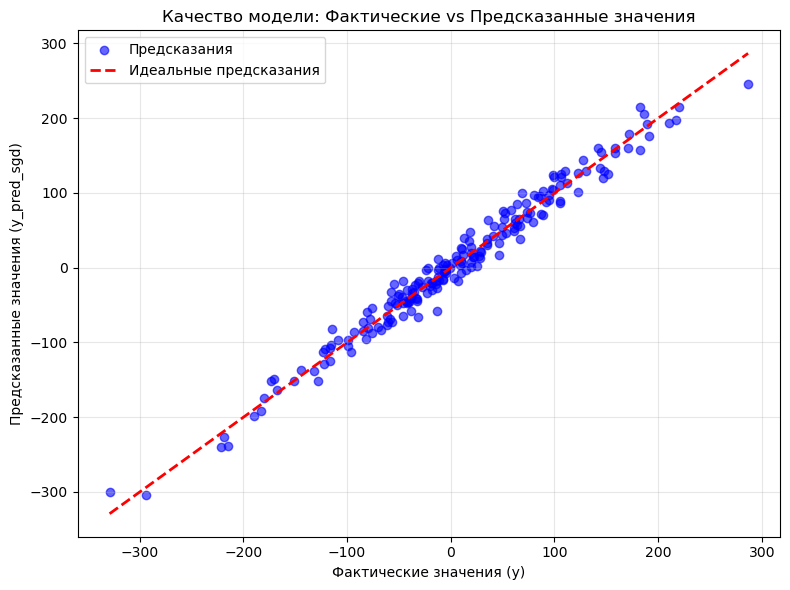

In [13]:
# Построение графика для оценки качества модели
plt.figure(figsize=(8, 6))

# Добавляем точки: фактические vs предсказанные значения
plt.scatter(y, y_pred_sgd, alpha=0.6, color='blue', label='Предсказания')

# Добавляем идеальную линию (где предсказанное = фактическому)
min_val = min(min(y), min(y_pred_sgd))
max_val = max(max(y), max(y_pred_sgd))
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Идеальные предсказания')

# Настройки графика
plt.xlabel('Фактические значения (y)')
plt.ylabel('Предсказанные значения (y_pred_sgd)')
plt.title('Качество модели: Фактические vs Предсказанные значения')
plt.legend()
plt.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

## После обучения: получение метрик качества


In [14]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_absolute_percentage_error, root_mean_squared_error
import numpy as np

mse = mean_squared_error(y, y_pred_sgd) # Ваша строка кода здесь
mae = mean_absolute_error(y, y_pred_sgd) # Ваша строка кода здесь
rmse = root_mean_squared_error(y, y_pred_sgd) # Ваша строка кода здесь
r2 = r2_score(y, y_pred_sgd) # Ваша строка кода здесь
# Для MAPE исключаем нулевые значения y, чтобы избежать деления на 0
non_zero_idx = y != 0
mape = mean_absolute_percentage_error(y[non_zero_idx], y_pred_sgd[non_zero_idx]) * 100 

# Вывод результатов
print("MSE:", round(mse, 3))
print("MAE:", round(mae, 3))
print("RMSE:", round(rmse, 3))
print("R²:", round(r2, 3))
print("MAPE:", round(mape, 3))

MSE: 221.916
MAE: 12.017
RMSE: 14.897
R²: 0.976
MAPE: 40.054


## Эксперимент чувствительности к параметрам модели


Уменьшим количество итераций и увеличим шаг обучения, чтобы увидеть, как это повлияет на качество модели.

In [16]:
model_sgd2 = SGDRegressor(
learning_rate='constant',  # фиксированный шаг обучения
eta0=0.1,                  # размер шага увеличен
max_iter=10,               # количество итераций теперь 10
tol=1e-3,                  # критерий останова
random_state=42            # для воспроизводимости
)

model_sgd2.fit(X, y)

# Выводим веса

print("Коэффициенты:", model_sgd2.coef_)
print("Свободный член:", model_sgd2.intercept_)



Коэффициенты: [ 2.02171931  8.74547922 63.21799125 20.24557836 65.40978685]
Свободный член: [-0.15353948]


In [17]:
# Предсказания

y_pred_sgd2 = model_sgd2.predict(X)
print("Первые 10 предсказаний:", y_pred_sgd2[:10]) 

Первые 10 предсказаний: [ -23.21487668 -130.06897297   -0.69445358  -70.75277193   12.76799123
 -183.18785043  -20.89672278   24.67693782  117.72957403  124.77651907]


Коэффициенты стали менее точными